In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, regularizers

import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_path = "/content/drive/MyDrive/ECE x ML/id_vg_characteristics/2nm/Simulated2/id_vg_grain_2nm_weff_60nm_lg12.csv"

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (202, 201)


,Voltage(V),I_d_1,I_d_2,I_d_3,I_d_4,I_d_5,I_d_6,I_d_7,I_d_8,I_d_9,...,I_d_191,I_d_192,I_d_193,I_d_194,I_d_195,I_d_196,I_d_197,I_d_198,I_d_199,I_d_200
0,-0.50,-2.151152e-20,1.228835e-20,-4.609843e-20,-1.228922e-20,-1.843824e-20,-3.071890e-21,6.147825e-21,-4.609726e-20,-1.536968e-20,...,-2.458448e-20,-3.073184e-20,-3.687485e-20,-3.994976e-20,-1.536883e-20,-3.072668e-21,-2.765990e-20,-5.838917e-20,-2.766421e-20,-4.608935e-20
1,-0.50,1.696573e-18,4.241680e-19,-3.869223e-19,1.139725e-19,-1.780858e-19,6.158425e-20,-1.625626e-19,1.569812e-19,8.616546e-20,...,1.906946e-19,-5.818614e-20,-8.273105e-20,1.559678e-20,1.791929e-18,5.442191e-19,2.179986e-20,-1.200660e-20,-4.889187e-20,-4.288465e-20
2,-0.49,2.797516e-19,2.735279e-19,2.612802e-19,2.155928e-20,1.598338e-19,8.609770e-20,3.842071e-19,1.545549e-20,3.687140e-20,...,-1.382093e-19,-3.625254e-19,-1.074817e-19,-2.457349e-19,-1.750702e-19,4.641428e-19,-1.781174e-19,-1.259119e-19,-1.228198e-19,1.566965e-19
3,-0.48,7.960314e-19,3.657125e-19,-2.454112e-20,1.014375e-19,-1.966469e-19,8.917434e-20,3.165586e-19,-1.044733e-19,2.335923e-19,...,2.181964e-19,-8.299421e-20,1.598207e-19,-7.682135e-20,7.376360e-20,1.690813e-19,-6.147311e-20,-1.598299e-19,1.076055e-19,1.413374e-19
4,-0.47,1.383480e-19,4.518161e-19,1.690710e-19,3.318800e-19,3.534853e-19,2.089959e-19,1.322340e-19,-7.376945e-20,3.718389e-19,...,1.291230e-19,4.917487e-20,7.072133e-20,-1.966247e-19,-3.067146e-20,2.704211e-19,2.120812e-19,-7.370319e-20,1.850629e-20,2.612459e-19


In [ ]:
# Remove unwanted columns
cols_to_drop = [c for c in df.columns if "Unnamed" in c or "Averge" in c]
df = df.drop(columns=cols_to_drop)

print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (202, 201)


In [ ]:
voltage = df.iloc[:,0].values.reshape(-1,1)

print("Voltage range:", voltage.min(), "to", voltage.max())

Voltage range: -0.5 to 1.5


In [ ]:
results_df = pd.DataFrame()

results_df[df.columns[0]] = df.iloc[:,0]   # Voltage

In [ ]:
save_dir = "/content/drive/MyDrive/ECE x ML/id_vg_characteristics/2nm/Predicted"

os.makedirs(save_dir, exist_ok=True)

save_file = os.path.join(save_dir, "id_vg_grain_2nm_weff_60nm_lg12_predicted.csv")

print("Results will be saved to:", save_file)

Results will be saved to: /content/drive/MyDrive/ECE x ML/id_vg_characteristics/2nm/Predicted/id_vg_grain_2nm_weff_60nm_lg12_predicted.csv


In [ ]:
start_seed = 1

if os.path.exists(save_file):
    print("Checkpoint found. Loading previous results...")

    results_df = pd.read_csv(save_file)

    processed_cols = results_df.shape[1] - 1
    start_seed = processed_cols // 2 + 1

    print("Resuming from seed:", start_seed)
else:
    print("Starting fresh run.")

Starting fresh run.


In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

eps = 1e-22

total_seeds = df.shape[1] - 1

for seed in range(start_seed, total_seeds + 1):

    print(f"\nProcessing Seed {seed}")

    try:

        # -----------------------------
        # Extract current column safely
        # -----------------------------
        y_series = pd.to_numeric(df.iloc[:, seed], errors="coerce")
        valid_mask = ~y_series.isna()

        X = voltage[valid_mask.values]
        y = y_series[valid_mask].values.reshape(-1,1)

        # -----------------------------
        # Physics-aware outlier removal
        # -----------------------------
        log_I = np.log10(np.abs(y) + eps)

        sub_mask = X.flatten() < -0.4
        log_I_sub = log_I[sub_mask]

        median = np.median(log_I_sub)
        mad = np.median(np.abs(log_I_sub - median))
        robust_sigma = 1.4826 * mad

        threshold = 2.5 * robust_sigma

        outliers = (np.abs(log_I - median) > threshold).flatten() & sub_mask

        X_clean = X[~outliers]
        y_clean = y[~outliers]

        # -----------------------------
        # Log target
        # -----------------------------
        y_log = np.log10(np.abs(y_clean) + eps)

        # If too few samples, skip seed
        if len(X_clean) < 20:
            print(f"Seed {seed} skipped (too few samples)")
            continue

        # -----------------------------
        # Train test split
        # -----------------------------
        X_train, X_test, y_train, y_test = train_test_split(
            X_clean, y_log, test_size=0.2, random_state=42
        )

        scaler = StandardScaler()

        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)

        # -----------------------------
        # Build ANN
        # -----------------------------
        model = tf.keras.Sequential([
            layers.Dense(64, activation="tanh",
                         kernel_regularizer=regularizers.l2(1e-4),
                         input_shape=(1,)),

            layers.Dense(64, activation="tanh",
                         kernel_regularizer=regularizers.l2(1e-4)),

            layers.Dense(32, activation="tanh",
                         kernel_regularizer=regularizers.l2(1e-4)),

            layers.Dense(1)
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(1e-3),
            loss="mse"
        )

        history = model.fit(
            X_train_s, y_train,
            epochs=500,
            batch_size=16,
            validation_split=0.2,
            callbacks=[
                tf.keras.callbacks.EarlyStopping(
                    monitor="val_loss",
                    patience=50,
                    restore_best_weights=True
                ),
                tf.keras.callbacks.ReduceLROnPlateau(
                    monitor="val_loss",
                    factor=0.2,
                    patience=20
                )
            ],
            verbose=0
        )

        # -----------------------------
        # Predict on full voltage grid
        # -----------------------------
        X_full_s = scaler.transform(voltage)

        y_log_pred = model.predict(X_full_s, verbose=0).flatten()

        I_pred = 10 ** y_log_pred

        # -----------------------------
        # Save actual and predicted
        # -----------------------------
        actual_col = df.columns[seed]
        pred_col = f"{actual_col}_Pred"

        results_df[actual_col] = df.iloc[:, seed]
        results_df[pred_col] = I_pred

        # -----------------------------
        # Save checkpoint every 10 seeds
        # -----------------------------
        if seed % 10 == 0:
            results_df.to_csv(save_file, index=False)
            print("Checkpoint saved.")

        tf.keras.backend.clear_session()

    except Exception as e:
        print(f"Seed {seed} skipped due to error: {e}")
        tf.keras.backend.clear_session()
        continue


Processing Seed 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Processing Seed 2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Processing Seed 3


...


Processing Seed 199


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/tmp/ipykernel_3503/3769698581.py:121: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  results_df[actual_col] = df.iloc[:, seed]
/tmp/ipykernel_3503/3769698581.py:122: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.


Processing Seed 200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/tmp/ipykernel_3503/3769698581.py:121: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  results_df[actual_col] = df.iloc[:, seed]
/tmp/ipykernel_3503/3769698581.py:122: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.

Checkpoint saved.


In [ ]:
results_df.to_csv(save_file, index=False)

print("All seeds processed.")
print("Final results saved to:", save_file)

All seeds processed.
Final results saved to: /content/drive/MyDrive/ECE x ML/id_vg_characteristics/2nm/Predicted/id_vg_grain_2nm_weff_60nm_lg12_predicted.csv


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/ECE x ML/id_vg_characteristics/2nm/Predicted/id_vg_grain_2nm_weff_60nm_lg12_predicted.csv"

results = pd.read_csv(file_path)

# find prediction columns
pred_cols = [c for c in results.columns if "_Pred" in c]

num_trained = len(pred_cols)

print("Number of seeds successfully trained:", num_trained)

total_seeds = 200
print("Total seeds expected:", total_seeds)

print("Skipped seeds:", total_seeds - num_trained)

Number of seeds successfully trained: 200
Total seeds expected: 200
Skipped seeds: 0


In [ ]:
trained_seeds = []

for col in pred_cols:
    # New format: 'I_d_1_Pred' -> split by '_' gives ['I', 'd', '1', 'Pred']
    # We take index 2, which is the number
    try:
        parts = col.split("_")
        seed_num = int(parts[2])
        trained_seeds.append(seed_num)
    except (IndexError, ValueError):
        print(f"Could not parse seed number from column: {col}")

all_seeds = list(range(1, total_seeds + 1))
skipped = sorted(set(all_seeds) - set(trained_seeds))

print("Number of seeds successfully trained:", len(trained_seeds))
print("Skipped seeds:", skipped)

Number of seeds successfully trained: 200
Skipped seeds: []


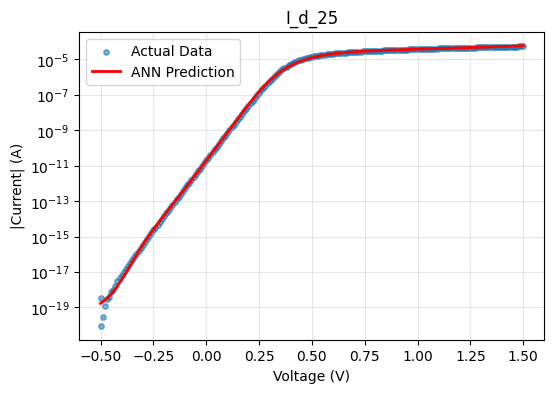

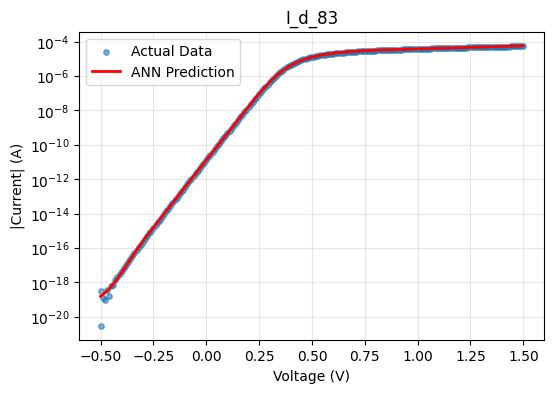

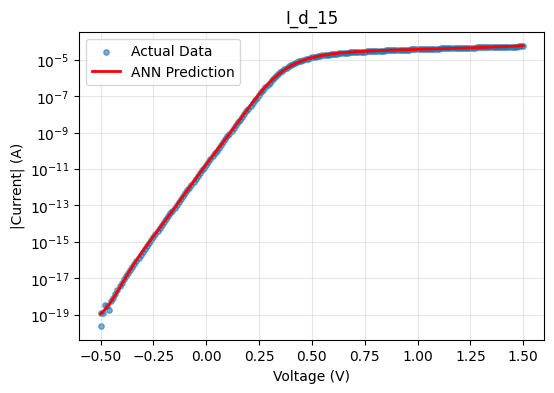

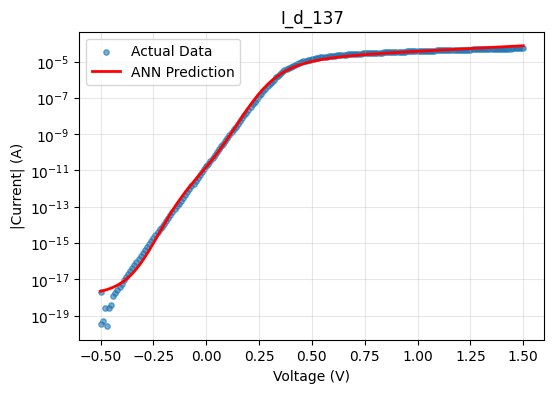

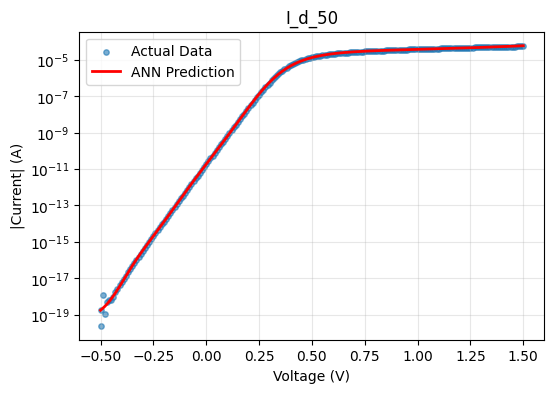

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

# load results again
file_path = "/content/drive/MyDrive/ECE x ML/id_vg_characteristics/2nm/Predicted/id_vg_grain_2nm_weff_60nm_lg12_predicted.csv"
results = pd.read_csv(file_path)

# voltage column
voltage = results.iloc[:,0].values

# prediction columns
pred_cols = [c for c in results.columns if "_Pred" in c]

# randomly choose seeds to plot
num_plots = 5
random_preds = random.sample(pred_cols, num_plots)

for pred_col in random_preds:

    actual_col = pred_col.replace("_Pred","")

    I_actual = np.abs(results[actual_col].values)
    I_pred = np.abs(results[pred_col].values)

    plt.figure(figsize=(6,4))

    plt.scatter(voltage, I_actual, s=15, alpha=0.6, label="Actual Data")
    plt.plot(voltage, I_pred, color="red", linewidth=2, label="ANN Prediction")

    plt.yscale("log")

    plt.xlabel("Voltage (V)")
    plt.ylabel("|Current| (A)")
    plt.title(actual_col)

    plt.legend()
    plt.grid(True, which="both", alpha=0.3)

    plt.show()

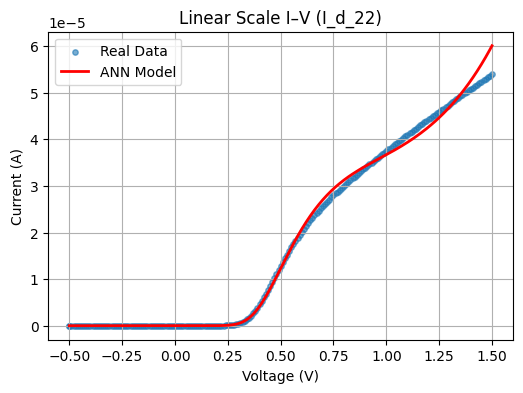

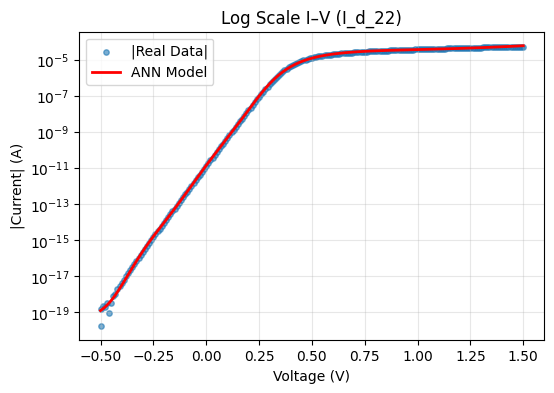

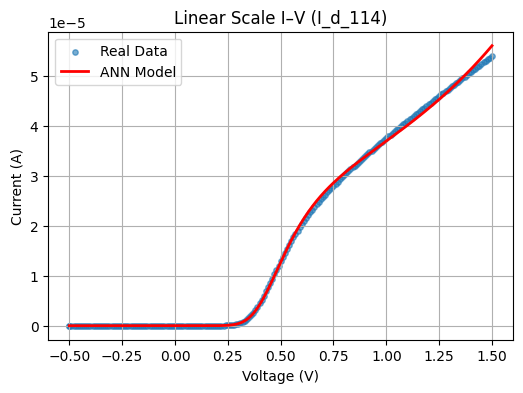

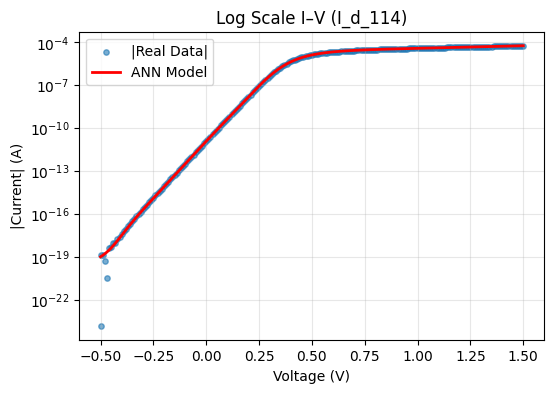

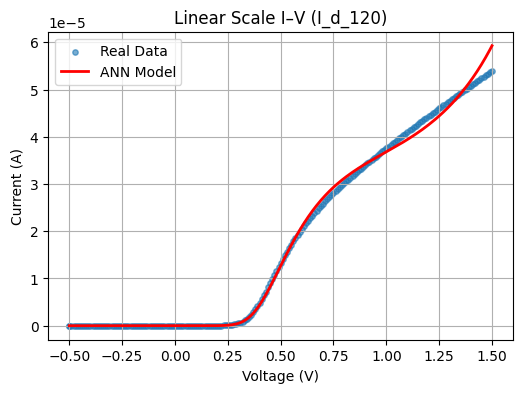

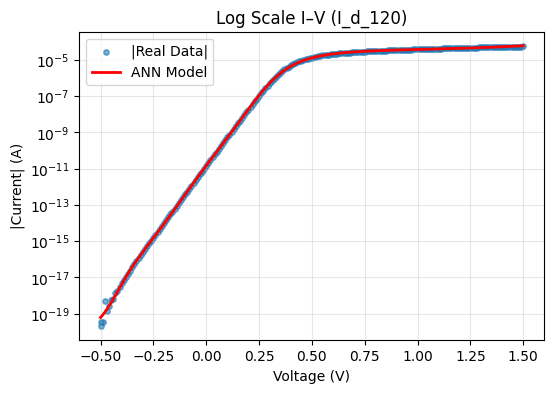

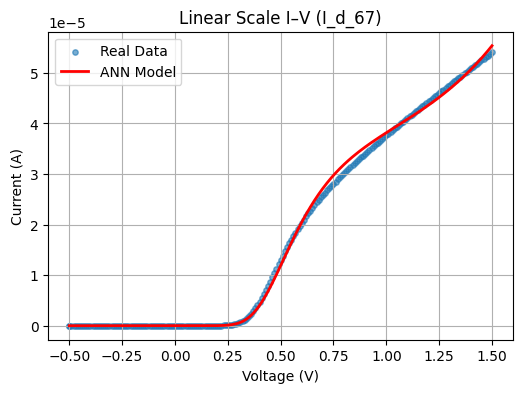

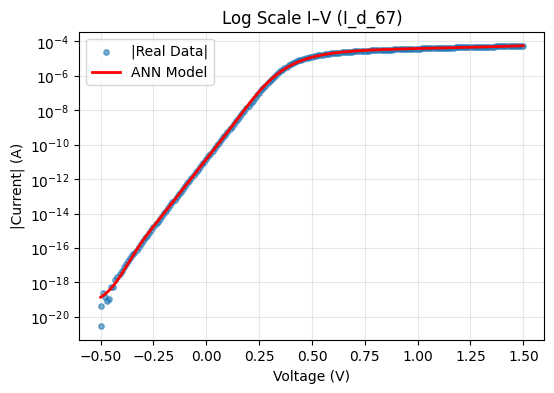

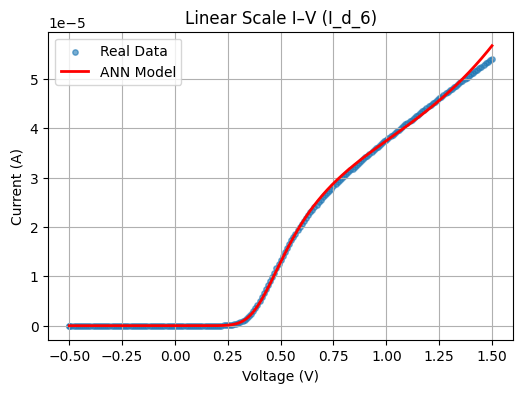

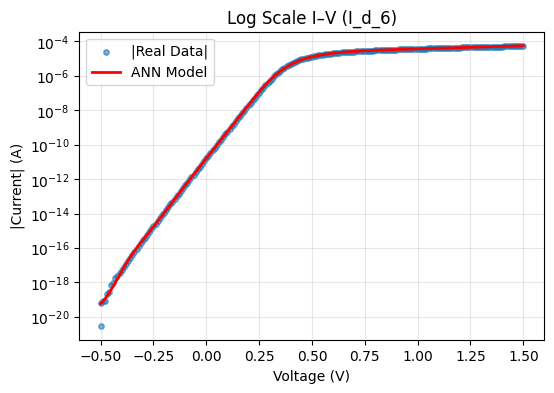

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

# load results
file_path = "/content/drive/MyDrive/ECE x ML/id_vg_characteristics/2nm/Predicted/id_vg_grain_2nm_weff_60nm_lg12_predicted.csv"
results = pd.read_csv(file_path)

# voltage
voltage = results.iloc[:,0].values

# prediction columns
pred_cols = [c for c in results.columns if "_Pred" in c]

# randomly choose seeds
num_plots = 5
random_preds = random.sample(pred_cols, num_plots)

for pred_col in random_preds:

    actual_col = pred_col.replace("_Pred","")

    I_actual = results[actual_col].values
    I_pred = results[pred_col].values

    # -----------------------------
    # Linear Scale Plot
    # -----------------------------
    plt.figure(figsize=(6,4))

    plt.scatter(voltage, I_actual, s=15, alpha=0.6, label="Real Data")
    plt.plot(voltage, I_pred, color="red", linewidth=2, label="ANN Model")

    plt.xlabel("Voltage (V)")
    plt.ylabel("Current (A)")
    plt.title(f"Linear Scale I–V ({actual_col})")

    plt.legend()
    plt.grid(True)

    plt.show()

    # -----------------------------
    # Log Scale Plot
    # -----------------------------
    plt.figure(figsize=(6,4))

    plt.scatter(voltage, np.abs(I_actual), s=15, alpha=0.6, label="|Real Data|")
    plt.plot(voltage, np.abs(I_pred), color="red", linewidth=2, label="ANN Model")

    plt.yscale("log")

    plt.xlabel("Voltage (V)")
    plt.ylabel("|Current| (A)")
    plt.title(f"Log Scale I–V ({actual_col})")

    plt.legend()
    plt.grid(True, which="both", alpha=0.3)

    plt.show()

In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Setup the 'separate' folder inside the 'Predicted' directory
separate_dir = os.path.join(save_dir, "separate")
os.makedirs(separate_dir, exist_ok=True)

# Generate the specific filenames for training and testing
# This takes '...weff52_predicted' and adds '_training' or '_testing'
base_name_only = os.path.basename(save_file).replace(".csv", "")
train_save_path = os.path.join(separate_dir, f"{base_name_only}_training.csv")
test_save_path = os.path.join(separate_dir, f"{base_name_only}_testing.csv")

# 2. Prepare for splitting
# Get the shared Voltage column
voltage = results_df.iloc[:, 0].values
voltage_col_name = results_df.columns[0]

# Identify Actual vs Predicted columns using the new standardized names
# e.g., 'I_d_1' and 'I_d_1_Pred'
actual_cols = [c for c in results_df.columns if c.startswith('I_d_') and not c.endswith('_Pred')]
pred_cols = [f"{c}_Pred" for c in actual_cols]

# Initialize the split DataFrames
df_train = pd.DataFrame({voltage_col_name: voltage})
df_test = pd.DataFrame({voltage_col_name: voltage})

def get_exact_split_indices(v_arr, i_arr):
    """
    Exact replication of the physics-aware logic from your training loop.
    """
    eps = 1e-22
    y_vals = pd.to_numeric(i_arr, errors="coerce")
    valid_mask = ~np.isnan(y_vals)

    indices = np.where(valid_mask)[0]
    X_valid = v_arr[valid_mask].reshape(-1, 1)
    y_valid = y_vals[valid_mask].reshape(-1, 1)

    # Physics-aware outlier removal
    log_I = np.log10(np.abs(y_valid) + eps)
    sub_mask = (X_valid < -0.4).flatten()
    log_I_sub = log_I[sub_mask]

    if len(log_I_sub) > 0:
        median = np.median(log_I_sub)
        mad = np.median(np.abs(log_I_sub - median))
        robust_sigma = 1.4826 * mad
        threshold = 2.5 * robust_sigma
        outliers = (np.abs(log_I - median) > threshold).flatten() & sub_mask
        idx_clean = indices[~outliers]
    else:
        idx_clean = indices

    if len(idx_clean) < 20:
        return None, None

    # REPLICATE SPLIT: Uses random_state=42 and test_size=0.2 exactly like training
    idx_train, idx_test = train_test_split(idx_clean, test_size=0.2, random_state=42)
    return idx_train, idx_test

# 3. Iterate and Separate
print(f"Splitting {len(actual_cols)} seeds into Train and Test sets...")

for actual_col, pred_col in zip(actual_cols, pred_cols):
    if pred_col not in results_df.columns:
        continue # Skip seeds that weren't trained

    current_actual = results_df[actual_col].values
    current_pred = results_df[pred_col].values

    idx_train, idx_test = get_exact_split_indices(voltage, current_actual)

    # Create empty arrays filled with NaN
    train_y, train_p = np.full(len(voltage), np.nan), np.full(len(voltage), np.nan)
    test_y, test_p = np.full(len(voltage), np.nan), np.full(len(voltage), np.nan)

    if idx_train is not None:
        # Assign values to the specific split indices
        train_y[idx_train] = current_actual[idx_train]
        train_p[idx_train] = current_pred[idx_train]
        test_y[idx_test] = current_actual[idx_test]
        test_p[idx_test] = current_pred[idx_test]

    # Add to result dataframes
    df_train[actual_col] = train_y
    df_train[pred_col] = train_p
    df_test[actual_col] = test_y
    df_test[pred_col] = test_p

# 4. Save to the new 'separate' folder
df_train.to_csv(train_save_path, index=False)
df_test.to_csv(test_save_path, index=False)

print("\nSuccess! Files saved in 'Predicted/separate/':")
print(f"- {os.path.basename(train_save_path)}")
print(f"- {os.path.basename(test_save_path)}")

Splitting 200 seeds into Train and Test sets...


/tmp/ipykernel_3503/232002204.py:89: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train[pred_col] = train_p
/tmp/ipykernel_3503/232002204.py:91: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_test[pred_col] = test_p
/tmp/ipykernel_3503/232002204.py:88: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()


Success! Files saved in 'Predicted/separate/':
- id_vg_grain_2nm_weff_60nm_lg12_predicted_training.csv
- id_vg_grain_2nm_weff_60nm_lg12_predicted_testing.csv


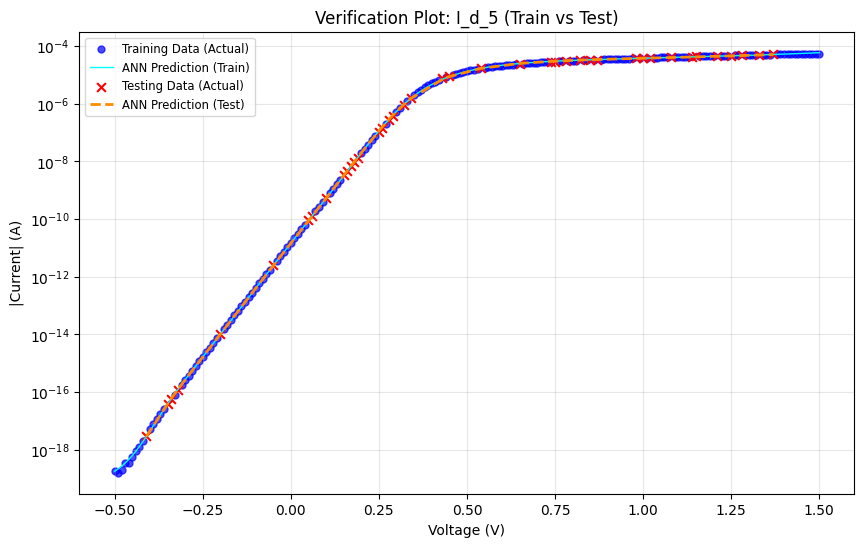

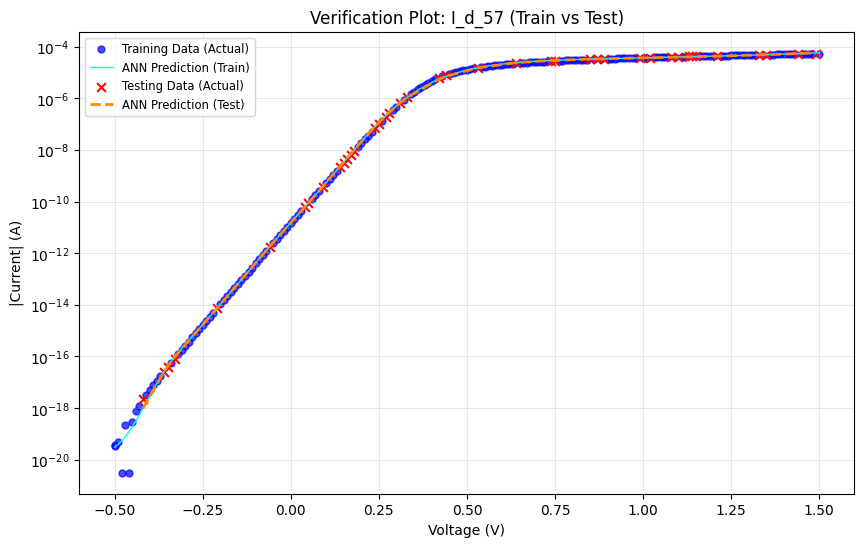

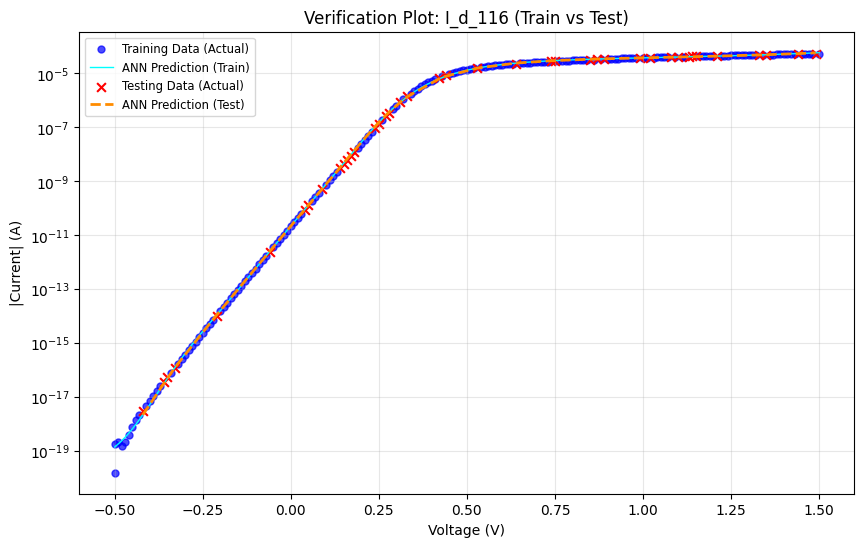

Verification plots complete. Blue dots were used for training, Red 'x' were hidden from the model.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import os

# 1. Define the paths to the newly created separate files
# (These variables should already be in your memory if you just ran the previous block)
# If not, you can manually paste the paths here.
train_path = train_save_path
test_path = test_save_path

# Load the split datasets
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

# 2. Get the shared Voltage column
voltage = df_train.iloc[:, 0].values

# 3. Identify seed columns (e.g., I_d_1, I_d_2...)
# We look for columns that don't end in '_Pred' and aren't the Voltage column
seed_cols = [c for c in df_train.columns if c.startswith('I_d_') and not c.endswith('_Pred')]

# 4. Randomly select 3 seeds to verify
num_samples = 3
random_seeds = random.sample(seed_cols, min(num_samples, len(seed_cols)))

for seed in random_seeds:
    pred_col = f"{seed}_Pred"

    # Extract Actual and Predicted for Train
    y_train_act = np.abs(df_train[seed])
    y_train_pred = np.abs(df_train[pred_col])

    # Extract Actual and Predicted for Test
    y_test_act = np.abs(df_test[seed])
    y_test_pred = np.abs(df_test[pred_col])

    # Create the plot
    plt.figure(figsize=(10, 6))

    # --- Plot Training Data ---
    plt.scatter(voltage, y_train_act, color='blue', s=25, alpha=0.7, label='Training Data (Actual)')
    # Overlay Training Prediction (using a line to see the model trend)
    # We drop NaNs to make the line continuous for the plot
    mask_train = ~np.isnan(y_train_pred)
    plt.plot(voltage[mask_train], y_train_pred[mask_train], color='cyan', linewidth=1, label='ANN Prediction (Train)')

    # --- Plot Testing Data ---
    plt.scatter(voltage, y_test_act, color='red', marker='x', s=40, label='Testing Data (Actual)')
    # Overlay Testing Prediction
    mask_test = ~np.isnan(y_test_pred)
    plt.plot(voltage[mask_test], y_test_pred[mask_test], color='darkorange', linestyle='--', linewidth=2, label='ANN Prediction (Test)')

    # Formatting
    plt.yscale('log')
    plt.xlabel('Voltage (V)')
    plt.ylabel('|Current| (A)')
    plt.title(f"Verification Plot: {seed} (Train vs Test)")
    plt.legend(loc='best', fontsize='small')
    plt.grid(True, which="both", alpha=0.3)

    plt.show()

print("Verification plots complete. Blue dots were used for training, Red 'x' were hidden from the model.")

In [ ]:
import time
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np

# 1. Initialize metrics and timing storage
metrics_list = []
eps = 1e-22

start_total_time = time.time()

print("Analyzing Accuracy Metrics and Computational Performance...")

for actual_col in actual_cols:
    seed_start_time = time.time()
    pred_col = f"{actual_col}_Pred"

    if pred_col not in results_df.columns:
        continue

    # Identify the Test split for evaluation
    idx_train, idx_test = get_exact_split_indices(voltage, results_df[actual_col].values)

    if idx_test is not None:
        y_true = results_df[actual_col].values[idx_test]
        y_pred = results_df[pred_col].values[idx_test]

        # --- Accuracy Metrics (Log Scale) ---
        log_y_true = np.log10(np.abs(y_true) + eps)
        log_y_pred = np.log10(np.abs(y_pred) + eps)

        r2 = r2_score(log_y_true, log_y_pred)
        rmse = np.sqrt(mean_squared_error(log_y_true, log_y_pred))
        mae = mean_absolute_error(log_y_true, log_y_pred)

        seed_end_time = time.time()
        seed_duration = seed_end_time - seed_start_time

        metrics_list.append({
            "Seed": actual_col,
            "R2_Score_Log": r2,
            "RMSE_Log": rmse,
            "MAE_Log": mae,
            "Execution_Time_Sec": seed_duration
        })

end_total_time = time.time()
total_duration = end_total_time - start_total_time

# 2. Create Summary DataFrame
performance_df = pd.DataFrame(metrics_list)

# 3. Calculate Overall Performance
avg_r2 = performance_df["R2_Score_Log"].mean()
avg_rmse = performance_df["RMSE_Log"].mean()
avg_time_per_seed = performance_df["Execution_Time_Sec"].mean()

print("\n" + "="*35)
print("Computational & Accuracy Summary")
print("="*35)
print(f"Total Seeds Evaluated:   {len(performance_df)}")
print(f"Average R2 Score (Log):  {avg_r2:.4f}")
print(f"Average RMSE (Log):      {avg_rmse:.4f}")
print(f"Average Time per Seed:   {avg_time_per_seed:.2f} seconds")
print(f"Total Execution Time:    {total_duration/60:.2f} minutes")
print("="*35)

# Display the performance table
performance_df.head(10)

Analyzing Accuracy Metrics and Computational Performance...

Computational & Accuracy Summary
Total Seeds Evaluated:   200
Average R2 Score (Log):  0.9998
Average RMSE (Log):      0.0462
Average Time per Seed:   0.00 seconds
Total Execution Time:    0.01 minutes


,Seed,R2_Score_Log,RMSE_Log,MAE_Log,Execution_Time_Sec
0,I_d_1,0.999177,0.111500,0.076537,0.004894
1,I_d_2,0.999924,0.032741,0.021788,0.002858
2,I_d_3,0.999726,0.064040,0.045639,0.003370
3,I_d_4,0.999841,0.048866,0.033361,0.003625
4,I_d_5,0.999979,0.017587,0.015021,0.003595
5,I_d_6,0.999951,0.027123,0.015972,0.003429
6,I_d_7,0.999904,0.037455,0.024406,0.003180
7,I_d_8,0.999827,0.051233,0.027590,0.002911
8,I_d_9,0.999888,0.040387,0.024997,0.002879
9,I_d_10,0.999493,0.086152,0.053149,0.003621
